In [7]:
import tensorflow as tf 
import matplotlib.pyplot as plt
import numpy as np

In [8]:

IMAGE_SIZE = 224
BATCH_SIZE = 32

In [9]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    directory="PlantVillage",
    shuffle=True,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
    )

Found 2152 files belonging to 3 classes.


In [10]:
class_names = dataset.class_names
print(class_names)

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']


In [11]:
def dataset_split(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size = 10000):

    ds_size = len(ds)
    if shuffle:
        ds = ds.shuffle(shuffle_size, seed = 12)
    train_ds = ds.take(int(train_split * ds_size))
    val_ds = ds.skip(int(train_split * ds_size)).take(int(val_split * ds_size))
    test_ds = ds.skip(int(train_split * ds_size)).skip(int(val_split * ds_size))
    return train_ds, val_ds, test_ds

In [12]:
train_ds, val_ds, test_ds = dataset_split(dataset)

In [13]:
print(len(train_ds), len(val_ds), len(test_ds))

54 6 8


In [14]:
train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [15]:
resize_rescale = tf.keras.Sequential([
    tf.keras.layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    tf.keras.layers.Rescaling(1./255)
    ])

In [16]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2)
])

In [17]:
model = tf.keras.Sequential([
    resize_rescale,
    data_augmentation,
    tf.keras.layers.Conv2D(32, (3,3), padding="same", activation="relu", input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3)),
    tf.keras.layers.MaxPool2D((2,2)),
    tf.keras.layers.Conv2D(32, (3,3), padding="same", activation="relu"),
    tf.keras.layers.MaxPool2D((2,2)),
    tf.keras.layers.Conv2D(32, (3,3), padding="same", activation="relu"),
    tf.keras.layers.MaxPool2D((2,2)),
    tf.keras.layers.Conv2D(32, (3,3), padding="same", activation="relu"),
    tf.keras.layers.MaxPool2D((2,2)),
    tf.keras.layers.Conv2D(32, (3,3), padding="same", activation="relu"),
    tf.keras.layers.MaxPool2D((2,2)),
    tf.keras.layers.Conv2D(32, (3,3), padding="same", activation="relu"),
    tf.keras.layers.MaxPool2D((2,2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation="relu"),
    tf.keras.layers.Dense(len(class_names), activation="softmax")
    
])

model.build(input_shape = (32, IMAGE_SIZE, IMAGE_SIZE, 3))
model.summary()

/home/rohan/miniconda3/envs/tf_gpu/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:99: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (32, 224, 224, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_3 (Sequential)       │ (32, 224, 224, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (32, 224, 224, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (32, 112, 112, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (32, 112, 112, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (32, 56, 56, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (32, 56, 56, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (32, 28, 28, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (32, 28, 28, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (32, 14, 14, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (32, 14, 14, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (32, 7, 7, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (32, 7, 7, 32)         │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (32, 3, 3, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (32, 288)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (32, 512)              │       147,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (32, 3)                │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 196,643 (768.14 KB)

 Trainable params: 196,643 (768.14 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"]
)

In [19]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor = "val_loss",
    patience = 5
)

In [20]:
history = model.fit(
    train_ds,
    epochs=20,
    batch_size = BATCH_SIZE,
    validation_data=val_ds,
    verbose=1,
    callbacks = [early_stopping]
)

Epoch 1/20


2026-04-10 15:10:18.317015: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:7: Filling up shuffle buffer (this may take a while): 21 of 10000
2026-04-10 15:10:01.262220: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


51/54 ━━━━━━━━━━━━━━━━━━━━ 2s 699ms/step - accuracy: 0.4751 - loss: 0.9479 

2026-04-10 15:10:38.364552: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:7: Filling up shuffle buffer (this may take a while): 17 of 10000
2026-04-10 15:10:20.449758: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.
2026-04-10 15:10:20.450425: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 19267712 bytes after encountering the first element of size 19267712 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


54/54 ━━━━━━━━━━━━━━━━━━━━ 23s 360ms/step - accuracy: 0.4782 - loss: 0.9428 - val_accuracy: 0.7135 - val_loss: 0.7473
Epoch 2/20


...

54/54 ━━━━━━━━━━━━━━━━━━━━ 20s 363ms/step - accuracy: 0.9666 - loss: 0.0817 - val_accuracy: 0.9948 - val_loss: 0.0192
Epoch 20/20


2026-04-10 15:16:49.114935: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:4: Filling up shuffle buffer (this may take a while): 203 of 256
2026-04-10 15:16:49.127808: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.
2026-04-10 15:16:31.324214: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.
2026-04-10 15:16:31.324521: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 19267712 bytes after encountering the first element of size 19267712 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


51/54 ━━━━━━━━━━━━━━━━━━━━ 2s 708ms/step - accuracy: 0.9905 - loss: 0.0312

2026-04-10 15:16:50.521932: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 19267712 bytes after encountering the first element of size 19267712 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


54/54 ━━━━━━━━━━━━━━━━━━━━ 21s 369ms/step - accuracy: 0.9902 - loss: 0.0322 - val_accuracy: 1.0000 - val_loss: 0.0305


In [21]:
test_eval = model.evaluate(test_ds)

1/8 ━━━━━━━━━━━━━━━━━━━━ 5s 833ms/step - accuracy: 1.0000 - loss: 0.0342

2026-04-10 15:16:51.990559: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 19267712 bytes after encountering the first element of size 19267712 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 121ms/step - accuracy: 0.9805 - loss: 0.0582


Text(0.5, 1.0, 'Training and Validation Accuracy')

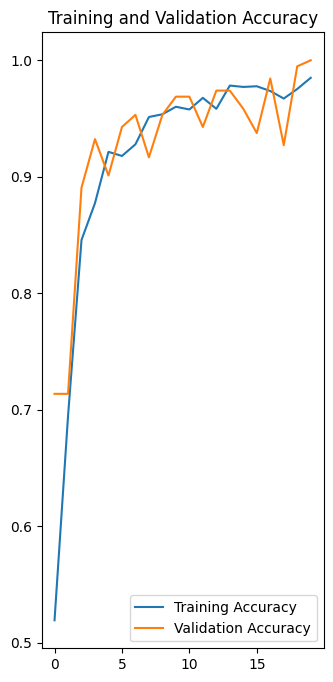

In [22]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]

loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs_range = range(len(acc))   # FIX HERE

plt.figure(figsize=(8, 8))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="Training Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.legend(loc="lower right")
plt.title("Training and Validation Accuracy")

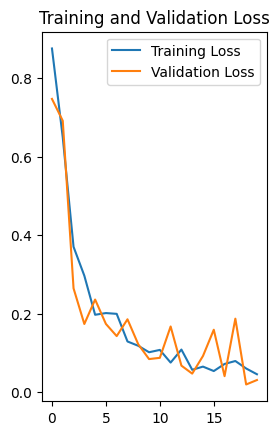

In [23]:
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.legend(loc="upper right")
plt.title("Training and Validation Loss")
plt.show()

2026-04-10 15:16:54.215638: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 19267712 bytes after encountering the first element of size 19267712 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step
Potato___Early_blight 0.98092914


2026-04-10 15:16:54.625814: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


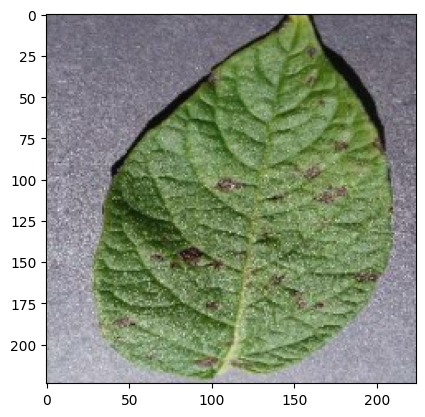

In [24]:
#! prediction 
for image_batch, labels_batch in test_ds.take(1):
    first_image = image_batch[0].numpy().astype("uint8")
    first_label = labels_batch[0].numpy()
    plt.imshow(first_image)

    batch_prediction = model.predict(image_batch)
    confidence = np.max(batch_prediction[0])
    print(class_names[np.argmax(batch_prediction[0])], confidence)
    

In [28]:
model.save("fixed_model_v2.keras")

In [29]:
load_model = tf.keras.models.load_model("fixed_model_v2.keras")

2026-04-10 15:21:24.234868: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 19267712 bytes after encountering the first element of size 19267712 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


Potato___Early_blight 1.0


2026-04-10 15:21:24.601662: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


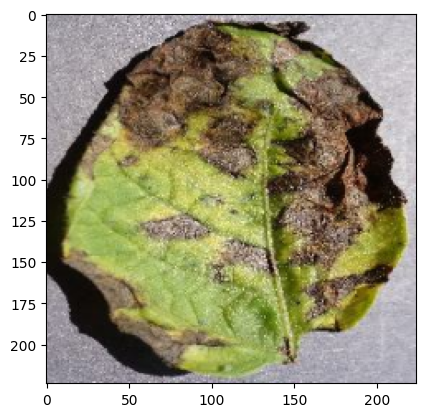

In [30]:
#! prediction 
for image_batch, labels_batch in test_ds.take(1):
    first_image = image_batch[0].numpy().astype("uint8")
    first_label = labels_batch[0].numpy()
    plt.imshow(first_image)

    batch_prediction = load_model.predict(image_batch, verbose=0)
    confidence = np.max(batch_prediction[0])
    print(class_names[np.argmax(batch_prediction[0])], confidence)
    

In [31]:
import tensorflow as tf

model = tf.keras.models.load_model("fixed_model_v2.keras")

In [32]:
model = tf.keras.Sequential(model.layers[:1] + model.layers[2:])

In [33]:
model.save("fixed_model_v2.keras")

/home/rohan/miniconda3/envs/tf_gpu/lib/python3.10/site-packages/keras/src/saving/saving_api.py:100: UserWarning: You are saving a model that has not yet been built. It might not contain any weights yet. Consider building the model first by calling it on some data.
  saving_lib.save_model(model, filepath)
